# 02 — Análisis Exploratorio de Datos

## Objetivo

Realizar un análisis exploratorio del portafolio sintético antes del ajuste
de modelos predictivos.

El análisis se centra exclusivamente en la información que estaría disponible
en un escenario real, estudiando:

- la estructura y calidad del conjunto de datos;
- la distribución de las variables explicativas;
- el comportamiento de la frecuencia de siniestros;
- la distribución de la severidad;
- el costo agregado por póliza;
- las relaciones entre características y variables objetivo.

Las variables *oracle* generadas por el DGP no se utilizarán durante el
análisis exploratorio principal.

In [26]:
from pathlib import Path
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
FEATURES = [
    "edad",
    "zona",
    "anios_vehiculo",
    "cobertura",
    "historial_siniestros",
    "tipo_uso"
]

In [28]:
DATA_PATH = Path("../data/raw/synthetic_insurance_portfolio.csv")


df = pd.read_csv(DATA_PATH)

print(f"Observaciones: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

df.head()

Observaciones: 10,000
Variables: 15


,policy_id,edad,zona,anios_vehiculo,cobertura,historial_siniestros,tipo_uso,numero_siniestros,tuvo_siniestro,severidad_promedio,costo_siniestros,lambda_real,prob_siniestro_real,severidad_esperada_real,prima_pura_real
0,1,23,2,0,0,3,0,0,0,NaN,0.0,0.185537,0.169342,6983.112407,1295.626965
1,2,62,2,14,0,4,0,0,0,NaN,0.0,0.280271,0.244421,8260.579323,2315.196861
2,3,55,3,4,0,2,0,0,0,NaN,0.0,0.180414,0.165076,8097.008893,1460.815324
3,4,43,4,14,2,0,1,0,0,NaN,0.0,0.198990,0.180442,20728.192310,4124.705903
4,5,42,2,11,0,1,0,0,0,NaN,0.0,0.138484,0.129323,7968.487662,1103.508579


## 1. Estructura y calidad de los datos

Aqui ya se esperaban NaN en severidad_promedio para las pólizas sin siniestros.

In [29]:
# Hay Na
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   policy_id                10000 non-null  int64  
 1   edad                     10000 non-null  int64  
 2   zona                     10000 non-null  int64  
 3   anios_vehiculo           10000 non-null  int64  
 4   cobertura                10000 non-null  int64  
 5   historial_siniestros     10000 non-null  int64  
 6   tipo_uso                 10000 non-null  int64  
 7   numero_siniestros        10000 non-null  int64  
 8   tuvo_siniestro           10000 non-null  int64  
 9   severidad_promedio       1423 non-null   float64
 10  costo_siniestros         10000 non-null  float64
 11  lambda_real              10000 non-null  float64
 12  prob_siniestro_real      10000 non-null  float64
 13  severidad_esperada_real  10000 non-null  float64
 14  prima_pura_real          10000 non

In [30]:
df.isna().sum()

policy_id                     0
edad                          0
zona                          0
anios_vehiculo                0
cobertura                     0
historial_siniestros          0
tipo_uso                      0
numero_siniestros             0
tuvo_siniestro                0
severidad_promedio         8577
costo_siniestros              0
lambda_real                   0
prob_siniestro_real           0
severidad_esperada_real       0
prima_pura_real               0
dtype: int64

In [31]:
print(f"Filas duplicadas: {df.duplicated().sum():,}")

Filas duplicadas: 0


### Análisis inicial

- **Edad:** La edad promedio es de aproximadamente 46 años, con una desviación
  estándar de 16.4 años. Los cuartiles se encuentran en 32, 46 y 60 años,
  respectivamente, lo que sugiere una distribución aproximadamente uniforme
  dentro del intervalo observado de 18 a 74 años.

- **Zona:** Los valores se encuentran entre 1 y 5, con media cercana a 3 y
  cuartiles en 2, 3 y 4. La distribución parece aproximadamente equilibrada
  entre las distintas zonas, lo cual deberá confirmarse mediante sus frecuencias.

- **Antigüedad del vehículo:** Los vehículos presentan una antigüedad promedio
  de 9.6 años. Los cuartiles 5, 10 y 15 sugieren una distribución aproximadamente
  uniforme entre 0 y 19 años.

- **Cobertura:** Es una variable categórica codificada numéricamente entre 0 y 2.
  Las medidas como media y desviación estándar tienen una interpretación
  limitada, por lo que resulta más apropiado analizar las proporciones de cada
  categoría.

- **Historial de siniestros:** El número histórico de siniestros presenta una
  media de 0.83 y una mediana de 1. Los cuartiles muestran una fuerte
  concentración en valores bajos, principalmente 0 y 1.

- **Tipo de uso:** Es una variable categórica codificada entre 0 y 2. La mediana
  y el tercer cuartil son iguales a 1, pero será necesario analizar las
  frecuencias de cada categoría para interpretar adecuadamente su distribución.

- **Variables objetivo:** La frecuencia observada es baja, con una media de
  0.155 siniestros por póliza y el 14.23% de las pólizas presentando al menos
  un siniestro. Como consecuencia, la mediana y el tercer cuartil del costo
  agregado son cero. La severidad se encuentra definida únicamente para las
  1,423 pólizas que presentaron al menos un siniestro.

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
policy_id,10000.0,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
edad,10000.0,45.794700,16.377636,18.000000,32.000000,46.000000,60.000000,74.000000
zona,10000.0,2.981000,1.410120,1.000000,2.000000,3.000000,4.000000,5.000000
anios_vehiculo,10000.0,9.571000,5.756846,0.000000,5.000000,10.000000,15.000000,19.000000
cobertura,10000.0,0.709500,0.784073,0.000000,0.000000,1.000000,1.000000,2.000000
historial_siniestros,10000.0,0.825500,1.031482,0.000000,0.000000,1.000000,1.000000,4.000000
tipo_uso,10000.0,0.593000,0.639994,0.000000,0.000000,1.000000,1.000000,2.000000
numero_siniestros,10000.0,0.155400,0.399082,0.000000,0.000000,0.000000,0.000000,4.000000
tuvo_siniestro,10000.0,0.142300,0.349375,0.000000,0.000000,0.000000,0.000000,1.000000
severidad_promedio,1423.0,12422.470478,8742.437938,1305.626001,6469.791646,10135.257484,15947.000784,90380.891559


In [33]:
# Definimos las categorias de las variables zona, cobertura y tipo_uso
df["zona_cat"] = df["zona"].map({
    1: "Muy bajo",
    2: "Bajo",
    3: "Medio",
    4: "Alto",
    5: "Muy alto"
})

df["cobertura_cat"] = df["cobertura"].map({
    0: "Limitada",
    1: "RC",
    2: "Amplia"
})

df["tipo_uso_cat"] = df["tipo_uso"].map({
    0: "Particular",
    1: "Transporte privado",
    2: "Carga comercial"
})

# Definir tambien el orden de las variables categoricas

orders = {
    "zona_cat": [
        "Muy bajo",
        "Bajo",
        "Medio",
        "Alto",
        "Muy alto"
    ],
    "cobertura_cat": [
        "Limitada",
        "RC",
        "Amplia"
    ],
    "historial_siniestros": [
        0, 1, 2, 3, 4
    ],
    "tipo_uso_cat": [
        "Particular",
        "Transporte privado",
        "Carga comercial"
    ]
}

## 2. Análisis de variables explicativas

Antes de estudiar las variables objetivo, se analiza la composición del
portafolio y la distribución de las características disponibles para los
modelos.

Las variables explicativas se dividen en:

**Numéricas**
- `edad`
- `anios_vehiculo`

**Categóricas u ordinales**
- `zona`
- `cobertura`
- `historial_siniestros`
- `tipo_uso`

Este análisis permite identificar desbalances, concentraciones y posibles
relaciones entre predictores antes de estudiar su asociación con la
siniestralidad.

### 2.1 Variables numéricas

En general, los histogramas son consistentes con lo que habiamos analizado al inicio con el resumen que genero `describe()`.

- Edad: La edad de la cartera tiene una distribución aproximadamente uniforme entre 18 a 74 años

- Antigüedad Vehículo: La antiguedad del vehiculo se distribuye uniformemente en el intervalo de 0 a 19 años.

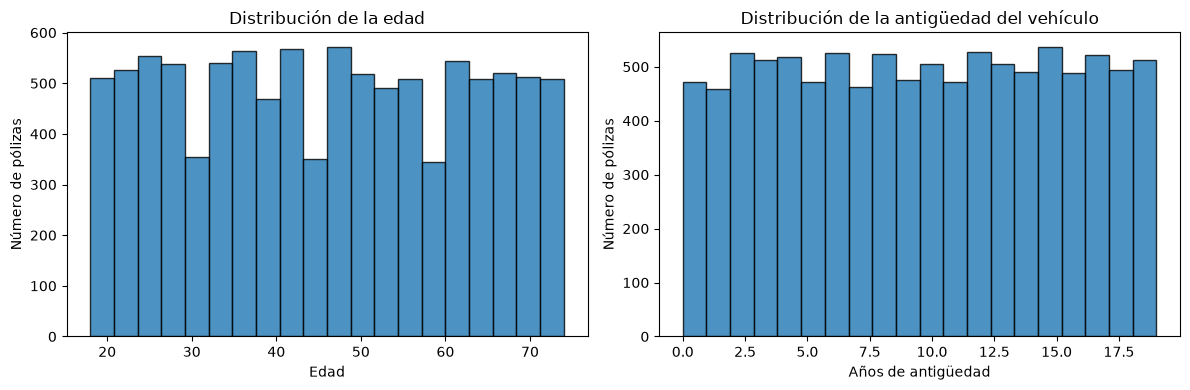

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df["edad"],
    bins=20,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribución de la edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Número de pólizas")

axes[1].hist(
    df["anios_vehiculo"],
    bins=20,
    edgecolor="black",
    alpha=0.8
)

axes[1].set_title("Distribución de la antigüedad del vehículo")
axes[1].set_xlabel("Años de antigüedad")
axes[1].set_ylabel("Número de pólizas")

plt.tight_layout()
plt.show()

### 2.2 Variables categóricas.

Analizaremos el comportamiento de las variables categóricas con tablas de frecuencia y con gráficos de barra.

- Zona: La tabla de frecuencia muestra proporciones aproximadas de 20% para cada una de las 5 zonas, y el gráfico de barra se me ve uniforme.

- Cobertura: La tabla de frecuencia muestra cierto desbalance entre cada cobetura, teniendo 50%, 30% y 20% para Limitada, RC y Amplia, respectivamente.

- Historial Siniestros: La cartera presenta una distribución concentrada en valores bajos, siendo aproximadamente el 50% de la cartera asegurados sin siniestros y para los sí tienen historial, se observa una tendencia a la baja en la frecuencia conforme aumenta la cantidad de siniestros

- Tipo de uso: La cartera está contruida principalmente por asegurados que utilizan sus vehículos de forma particular (50%) o para transporte privado (42%), solo el 8% de los asegurados lo usan para carga comercial

In [35]:
categorical_vars = [
    "zona_cat",
    "cobertura_cat",
    "historial_siniestros",
    "tipo_uso_cat"
]

for col in categorical_vars:
    resumen = (
        df[col]
        .value_counts(dropna=False)
        .reindex(orders[col])
        .rename("frecuencia")
        .to_frame()
    )

    resumen["proporcion"] = (
        resumen["frecuencia"] / len(df)
    )

    display(resumen)

,frecuencia,proporcion
zona_cat,,
Muy bajo,2025,0.2025
Bajo,2036,0.2036
Medio,1970,0.1970
Alto,2042,0.2042
Muy alto,1927,0.1927


,frecuencia,proporcion
cobertura_cat,,
Limitada,4948,0.4948
RC,3009,0.3009
Amplia,2043,0.2043


,frecuencia,proporcion
historial_siniestros,,
0,4984,0.4984
1,2846,0.2846
2,1392,0.1392
3,487,0.0487
4,291,0.0291


,frecuencia,proporcion
tipo_uso_cat,,
Particular,4911,0.4911
Transporte privado,4248,0.4248
Carga comercial,841,0.0841


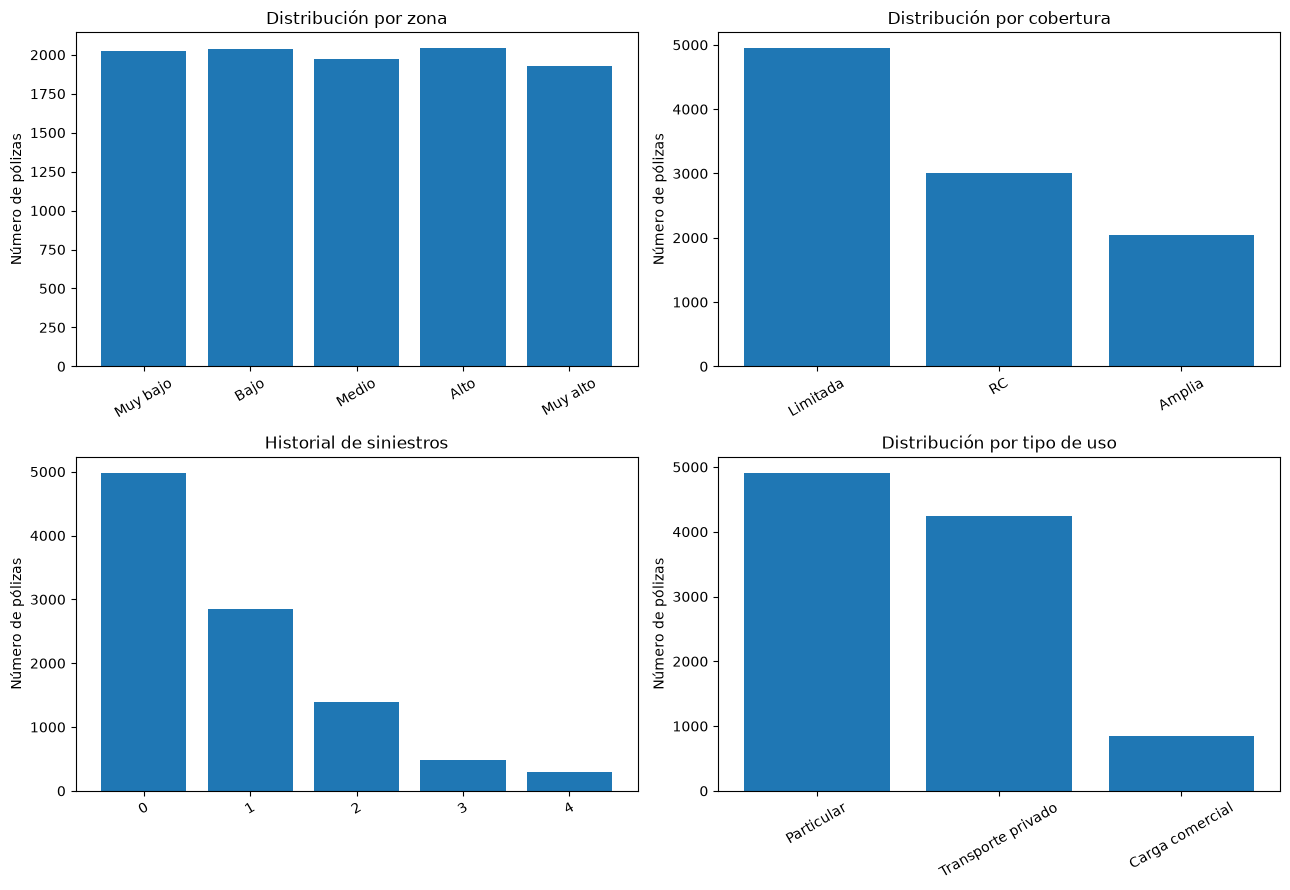

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

variables = [
    ("zona_cat", "Distribución por zona"),
    ("cobertura_cat", "Distribución por cobertura"),
    ("historial_siniestros", "Historial de siniestros"),
    ("tipo_uso_cat", "Distribución por tipo de uso")
]

for ax, (col, title) in zip(axes.flat, variables):
    counts = df[col].value_counts().reindex(orders[col])

    ax.bar(
        counts.index.astype(str),
        counts.values
    )

    ax.set_title(title)
    ax.set_ylabel("Número de pólizas")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 2.3 Relación entre variables explicativas

#### A. Relación entre las variables numéricas

La correlación de Pearson entre la edad del asegurado y la antigüedad del
vehículo es aproximadamente 0.017, indicando una asociación lineal
prácticamente nula.

Este resultado es consistente con el diagrama de dispersión, en el cual
no se observa un patrón creciente, decreciente o alguna otra estructura
evidente entre ambas variables.

Por lo tanto, no se identifica una relación lineal relevante entre la edad
del asegurado y la antigüedad de su vehículo.

In [37]:
# Calcular correlación
df[
    ["edad", "anios_vehiculo"]
].corr()

,edad,anios_vehiculo
edad,1.000000,0.017286
anios_vehiculo,0.017286,1.000000


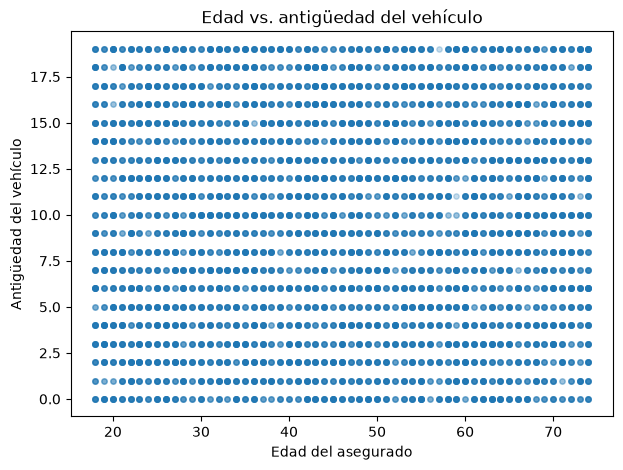

In [38]:
# Grafico
plt.figure(figsize=(7, 5))

plt.scatter(
    df["edad"],
    df["anios_vehiculo"],
    alpha=0.25,
    s=15
)

plt.xlabel("Edad del asegurado")
plt.ylabel("Antigüedad del vehículo")
plt.title("Edad vs. antigüedad del vehículo")

plt.show()

#### B. Numéricas vs categóricas

Los boxplots de edad y antigüedad del vehículo presentan distribuciones
similares entre las distintas categorías de zona, cobertura, historial de
siniestros y tipo de uso.

Las medianas, rangos intercuartílicos y dispersión general permanecen
relativamente estables entre grupos, por lo que no se observan asociaciones
relevantes entre las variables numéricas y categóricas a partir de este
análisis exploratorio.

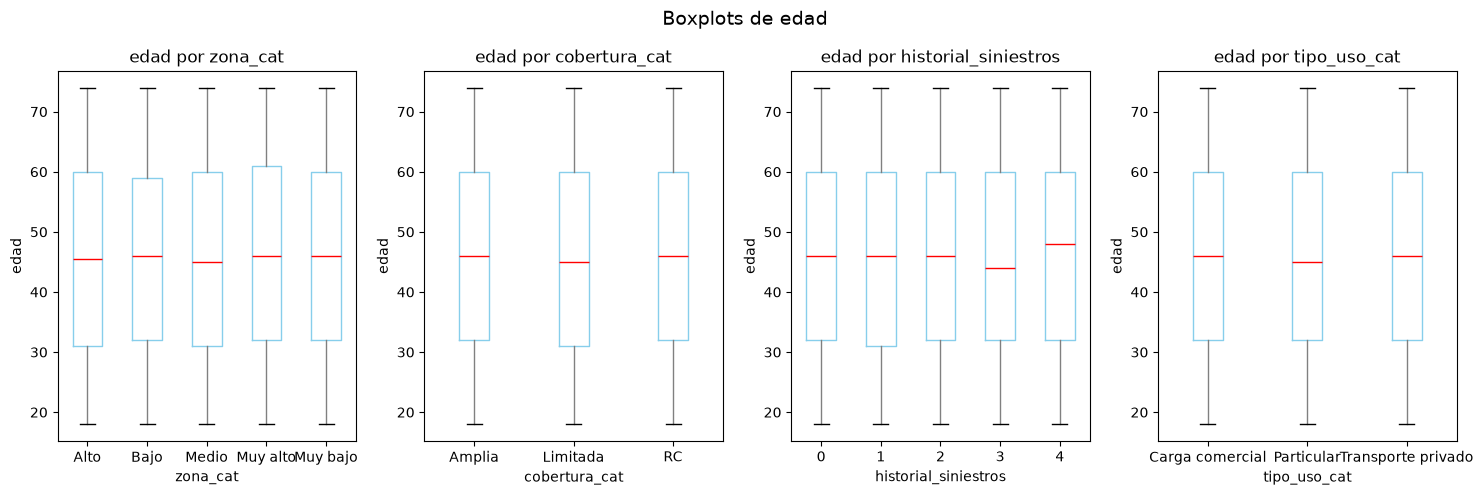

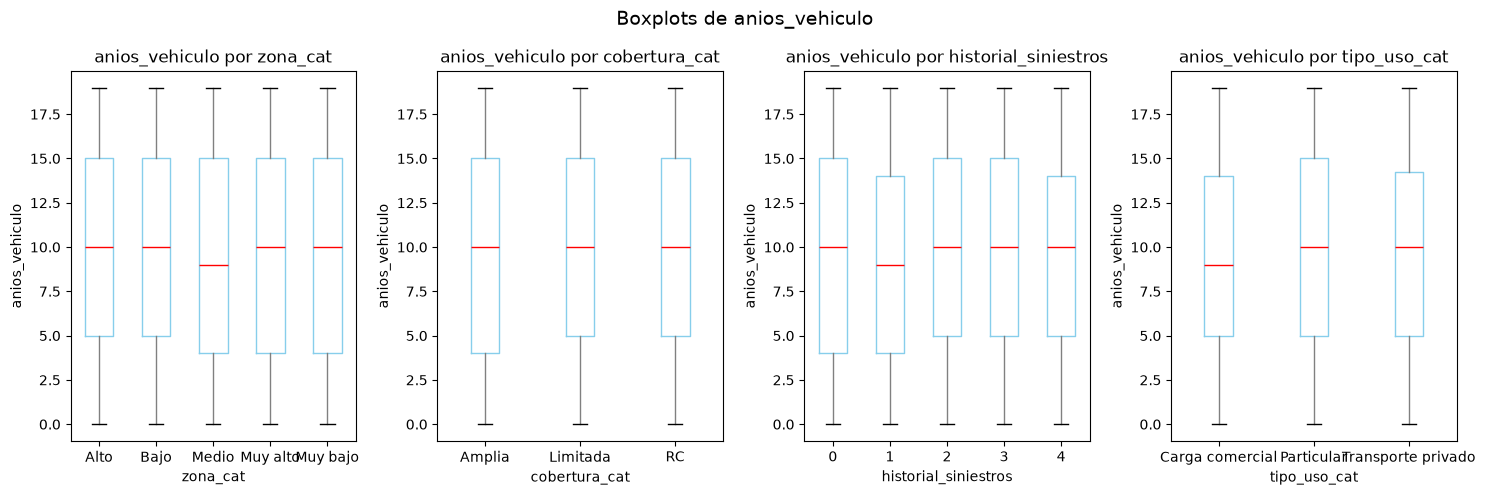

In [39]:
for numerico in ['edad', 'anios_vehiculo']:
    fig, axes = plt.subplots(1, len(categorical_vars), figsize=(15, 5))
    axes = axes.flatten()

    for i, categorica in enumerate(categorical_vars):
        df.boxplot(
            column=numerico,
            by=categorica,
            grid=False,
            ax=axes[i],
            color={'boxes':'skyblue', 'whiskers':'gray', 'medians':'red', 'caps':'black'}
        )
        axes[i].set_title(f'{numerico} por {categorica}')
        axes[i].set_xlabel(categorica)
        axes[i].set_ylabel(numerico)

    fig.suptitle(f'Boxplots de {numerico}', fontsize=14)
    plt.tight_layout()
    plt.show()


#### C. Categórica vs Categórica

Las tablas de contingencia muestran que las proporciones de las categorías
se mantienen aproximadamente estables al condicionar por las demás variables
categóricas.

No se identifican, por tanto, asociaciones evidentes entre las variables
categóricas del portafolio.

**Nota**: Este resultado no constituye por sí mismo una demostración estadística de
independencia, sino evidencia exploratoria de una asociación débil o
prácticamente inexistente.

In [40]:
# Vamos a generar tablas de contingencia normalizadas, para ver distribución entre categorias
tablas_crosstab = {}

for i, var1 in enumerate(categorical_vars):
    for j, var2 in enumerate(categorical_vars):
        if var1 != var2:  # evitar comparar la misma variable consigo misma
            nombre_tabla = f"{var1}_vs_{var2}"
            tablas_crosstab[nombre_tabla] = pd.crosstab(
                df[var1],
                df[var2],
                normalize="index"
            ) * 100 # porcentajes


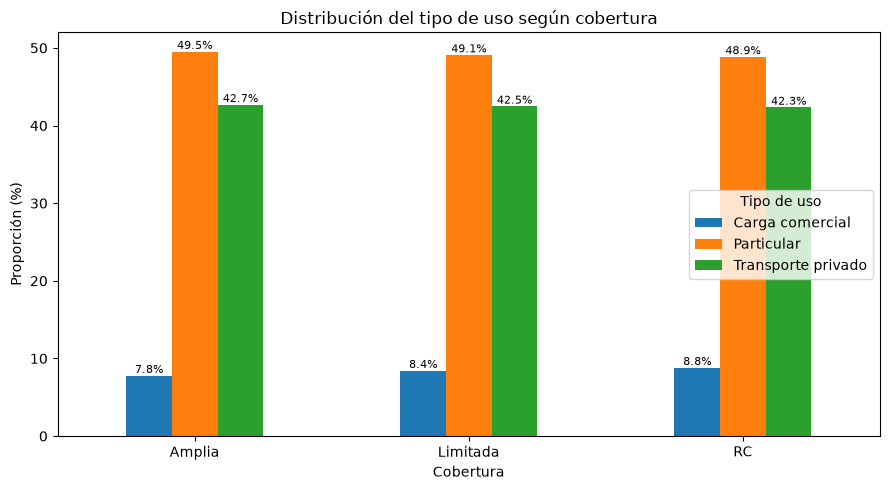

In [41]:

Analisis_completo = False # Cambiar a False una vez viendo los gráficos, para solo mostrar uno de ejemplo
if Analisis_completo:
    # Graficamos todas las tablas en subplots
    fig, axes = plt.subplots(len(tablas_crosstab), 1, figsize=(10, 5*len(tablas_crosstab)))

    if len(tablas_crosstab) == 1:
        axes = [axes]  # asegurar que sea iterable

    for ax, (nombre, tabla) in zip(axes, tablas_crosstab.items()):
        tabla.plot(kind="bar", ax=ax)

        ax.set_title(f"Distribución de {nombre.replace('_vs_', ' según ')}")
        ax.set_xlabel(nombre.split("_vs_")[0])
        ax.set_ylabel("Proporción (%)")
        ax.legend(title=nombre.split("_vs_")[1])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

        # 🔑 Agregar etiquetas de porcentaje encima de cada barra
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(9, 5)) 
    tablas_crosstab["cobertura_cat_vs_tipo_uso_cat"].plot(kind="bar", ax=ax)
    plt.title("Distribución del tipo de uso según cobertura")
    plt.xlabel("Cobertura")
    plt.ylabel("Proporción (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Tipo de uso")

      # 🔑 Agregar etiquetas de porcentaje encima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8)

    plt.tight_layout()
    plt.show()


**D. Correlación de Spearman**

La correlación de Spearman se utiliza únicamente como diagnóstico exploratorio.
Algunas variables se encuentran codificadas numéricamente a pesar de representar
categorías, por lo que sus coeficientes no deben interpretarse como medidas
completas de asociación entre dichas variables.

Los coeficientes obtenidos se encuentran próximos a cero, lo que complementa
los resultados anteriores y no muestra evidencia de relación monotona
relevante entre las variables explicativas.

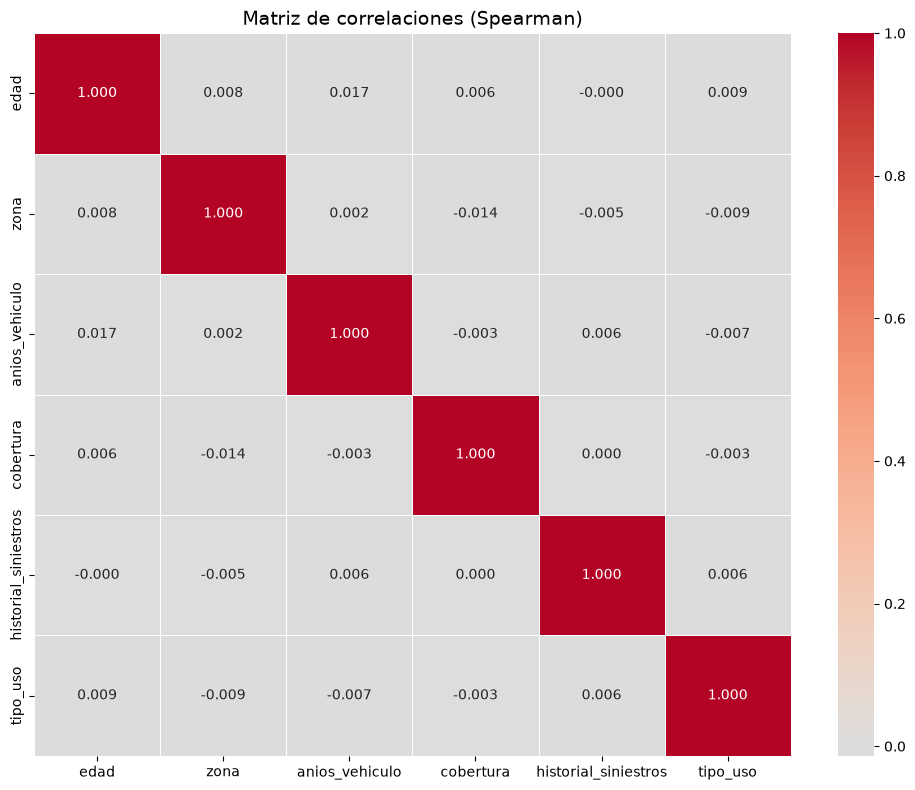

In [42]:
corr_spearman = df[FEATURES].corr(method="spearman")

# Gráfico tipo heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    annot=True,        # muestra los valores en cada celda
    fmt=".3f",         # formato de los números
    cmap="coolwarm",   # paleta de colores
    center=0,          # centrar la paleta en 0
    linewidths=0.5     # líneas entre celdas
)

plt.title("Matriz de correlaciones (Spearman)", fontsize=14)
plt.tight_layout()
plt.show()

### Conclusión

En conjunto, el análisis exploratorio no muestra relaciones relevantes entre
las variables explicativas del portafolio. Las distribuciones de las variables
numéricas permanecen estables entre categorías y las proporciones de las
variables categóricas tampoco presentan cambios sustanciales al condicionarlas
por otras características.

Esto permitirá estudiar posteriormente la relación de cada característica con
la siniestralidad sin que existan asociaciones fuertes entre los predictores
que dificulten su interpretación.

## 3. Análisis de frecuencia de siniestros

En esta sección se analiza el número de siniestros observados por póliza y su
relación con las características del portafolio.

La variable principal es `numero_siniestros`, que representa un conteo
no negativo. El objetivo del análisis es identificar:

- la distribución de la frecuencia observada;
- la proporción de pólizas sin siniestros;
- la frecuencia media según las características del riesgo;
- posibles relaciones no lineales;
- posibles interacciones entre factores de riesgo.

Este análisis se realiza utilizando únicamente información observable. Las
variables *oracle* del proceso generador no se utilizarán en esta etapa.

### 3.1 Distribución de la frecuencia

Observemos que el 86% de la población no tiene siniestros, y el 13% ha tenido un siniestro, eso deja solo a poco más del 1% con al menos 2 siniestros.

Además la cantidad total de siniestros de la cartera es de 1,554 dejando una frecuencia media de 15.54%, lo cuál es bastante consistente con las polizas que tienen al menos un siniestros 14.23%.

Observando el histograma, podemos ver que tiene un comportamiento similar a una distribución poisson, además de que estamos frente a un problema de conteo, por lo que esta distribución podria ser de utilidad.

In [43]:
freq_table = (
    df["numero_siniestros"]
    .value_counts()
    .sort_index()
    .rename("polizas")
    .to_frame()
)

freq_table["proporcion"] = (
    freq_table["polizas"] / len(df)
)


freq_table

,polizas,proporcion
numero_siniestros,,
0,8577,0.8577
1,1300,0.1300
2,116,0.0116
3,6,0.0006
4,1,0.0001


In [44]:
n_claims = df["numero_siniestros"].sum()
mean_frequency = df["numero_siniestros"].mean()
claim_rate = df["tuvo_siniestro"].mean()

print(f"Número total de siniestros: {n_claims:,}")
print(f"Frecuencia media: {mean_frequency:.4f}")
print(f"Pólizas con al menos un siniestro: {claim_rate:.2%}")

Número total de siniestros: 1,554
Frecuencia media: 0.1554
Pólizas con al menos un siniestro: 14.23%


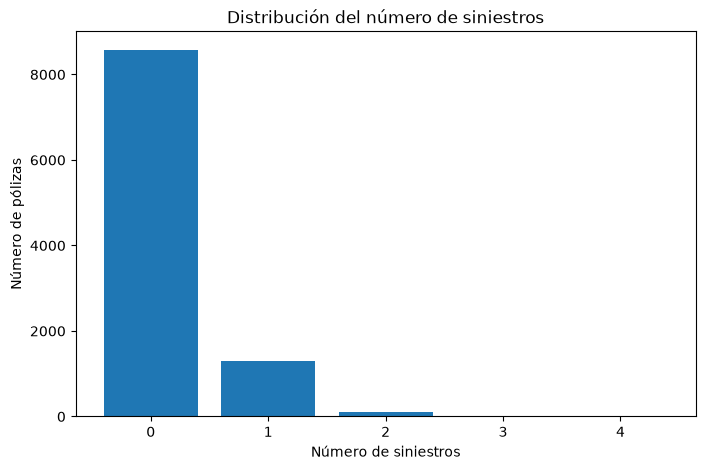

In [45]:
counts = (
    df["numero_siniestros"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.title("Distribución del número de siniestros")
plt.xlabel("Número de siniestros")
plt.ylabel("Número de pólizas")

plt.show()

### 3.2 Media y varianza del conteo

Analizar la media, varianza así como su división es importante en este tema, principalmente porque al ser frecuencia una variable discreta de conteo, naturalmente quisieramos modelar su comportamiento con una distribución Poisson o Binomial negativa y ver el comportamiento de este cociente nos puede ayudar a comprender cuál será el camino a seguir.

Ya que estas distribuciones tienen una propiedad muy importante

Sea $X$ una v.a. con distribución Poisson, se cumple:
$$E[X] = Var[X]$$

Sea $Y$ una v.a. con distribución Binomial Negativa, se cumple:

$$E[x] < Var[x]$$

Por lo que, si nuestra muestra cumple que $$\frac{Var[x]}{E[x]} > 1$$

La Binomial Negativa podria ser una mejor opción.

Particularmente para esta base, la media y varianza son bastante similares, dandonos un cociente de 1.025. Esto nos indica que una distribución Poisson será un buen ajuste.

In [46]:
mean_count = df["numero_siniestros"].mean()
variance_count = df["numero_siniestros"].var()

print(f"Media: {mean_count:.4f}")
print(f"Varianza: {variance_count:.4f}")
print(f"Varianza / Media: {variance_count / mean_count:.4f}")

Media: 0.1554
Varianza: 0.1593
Varianza / Media: 1.0249


### 3.3 Frecuencia segun factores de riesgo

Con apoyo de las tablas de frecuencia y los graficos de barras, podemos observar los siguiente:

- Zona: La frecuencia tiene una tendencia a la alta respecto a esta variable, subiendo de 11.16% para zonas muy bajas hasta 21.79%  para la zona muy alta.

- Cobertura: La cobertura Limitada y RC tienen una frecuencia similar (aproximadamente 14.6%), pero la cobertura Amplia tiene una frecuencia de 18.84%.

- Historial de siniestros: La frecuencia va aumentando conforme tienes más siniestros en tu historial, pasando de 10.51% si nunca has tenido un siniestro hasta 37.45% sin ya tienes un historial con 4 siniestros, esta variabilidad indica que esta variable podria ser un gran discriminador al momento de modelar la frecuencia.

- Tipo de uso: La frecuencia varia dependiendo el uso que se le dá al vehículo que se aseguro, si es de uso particular la frecuencia es de 14.98%, si es un vehículo de transporte privado tiene una frecuencia de 15.70% y si es de carga la frecuencia sube a 17.95%.

In [47]:
def frequency_summary(df, variable):
    summary = ( df.groupby(variable, observed=True)
    .agg(
        polizas=("numero_siniestros", "size"),
        siniestros=("numero_siniestros", "sum"),
        frecuencia=("numero_siniestros", "mean"),
        proporcion_con_siniestro=("tuvo_siniestro", "mean")
    )
    .reset_index()   )   # <- convierte el índice en columna

    if variable in orders:
        summary[variable] = pd.Categorical(summary[variable],
                                           categories=orders[variable],
                                           ordered=True)
        summary = summary.sort_values(variable)

    return summary


In [48]:
for categoria in categorical_vars:
    print(categoria.upper())
    display(frequency_summary(df,categoria))
    print()


ZONA_CAT


,zona_cat,polizas,siniestros,frecuencia,proporcion_con_siniestro
4,Muy bajo,2025,226,0.111605,0.107160
1,Bajo,2036,268,0.131631,0.123281
2,Medio,1970,283,0.143655,0.130457
0,Alto,2042,357,0.174829,0.159158
3,Muy alto,1927,420,0.217955,0.193565



COBERTURA_CAT


,cobertura_cat,polizas,siniestros,frecuencia,proporcion_con_siniestro
1,Limitada,4948,728,0.147130,0.136823
2,RC,3009,441,0.146560,0.135593
0,Amplia,2043,385,0.188448,0.165443



HISTORIAL_SINIESTROS


,historial_siniestros,polizas,siniestros,frecuencia,proporcion_con_siniestro
0,0,4984,524,0.105136,0.099719
1,1,2846,457,0.160576,0.148981
2,2,1392,320,0.229885,0.201868
3,3,487,144,0.295688,0.266940
4,4,291,109,0.374570,0.312715



TIPO_USO_CAT


,tipo_uso_cat,polizas,siniestros,frecuencia,proporcion_con_siniestro
1,Particular,4911,736,0.149868,0.136428
2,Transporte privado,4248,667,0.157015,0.145009
0,Carga comercial,841,151,0.179548,0.162901


In [49]:
def plot_frequency(df, variable, order=None, title=None):
    summary = frequency_summary(df, variable)

    if order is not None:
        summary[variable] = pd.Categorical(
            summary[variable],
            categories=order,
            ordered=True
        )
        summary = summary.sort_values(variable)

    plt.figure(figsize=(8, 5))

    plt.bar(
        summary[variable].astype(str),
        summary["frecuencia"]
    )

    plt.title(title or f"Frecuencia según {variable}")
    plt.xlabel(variable)
    plt.ylabel("Siniestros promedio por póliza")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

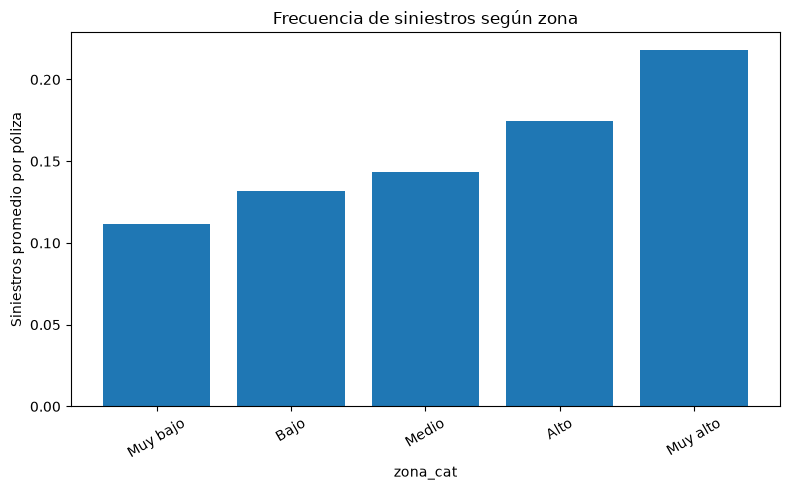

In [50]:
plot_frequency(
    df,
    "zona_cat",
    order=["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"],
    title="Frecuencia de siniestros según zona"
)

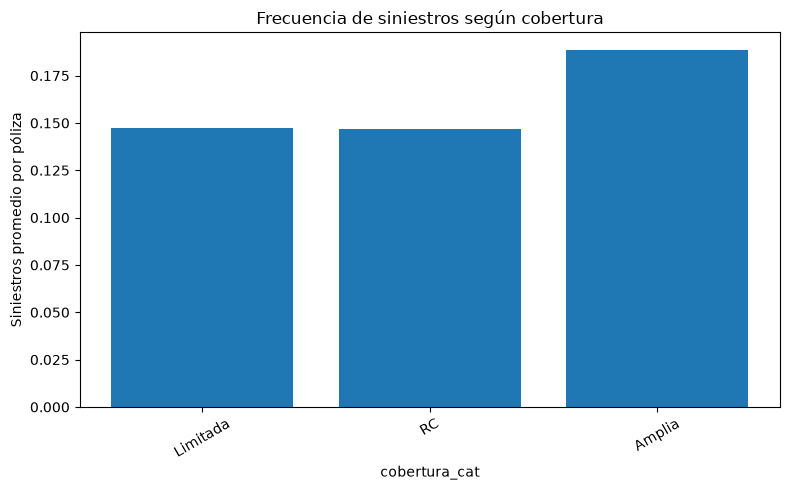

In [52]:
plot_frequency(
    df,
    "cobertura_cat",
    order=["Limitada", "RC", "Amplia"],
    title="Frecuencia de siniestros según cobertura"
)

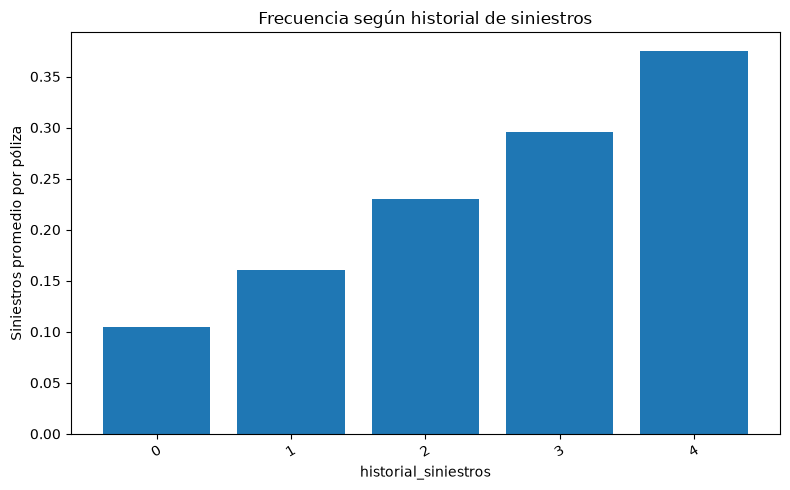

In [53]:
plot_frequency(
    df,
    "historial_siniestros",
    order=[0, 1, 2, 3, 4],
    title="Frecuencia según historial de siniestros"
)

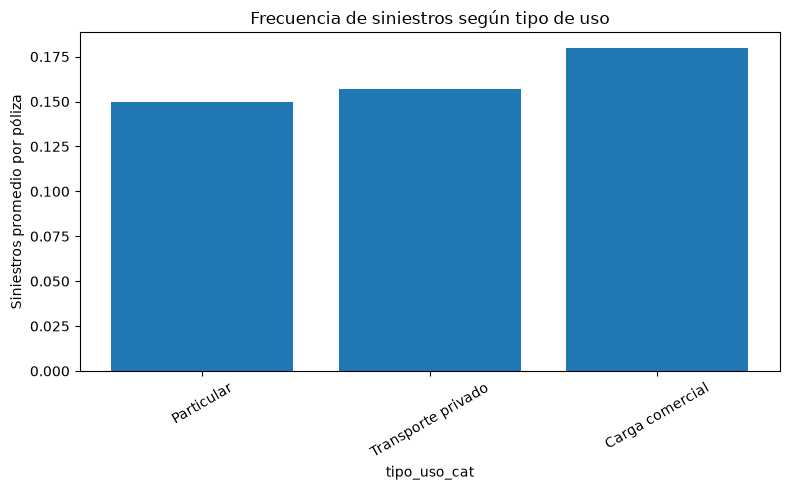

In [54]:
plot_frequency(
    df,
    "tipo_uso_cat",
    order=["Particular", "Transporte privado", "Carga comercial"],
    title="Frecuencia de siniestros según tipo de uso"
)

### 3.4 Frecuencia por grupo de edad

Para la variable edad no se observa un comportamiento lineal donde se pueda ver una sola tendencia.

El grupo de edad de 18-25 años tiene una frecuencia de 14.41% va en aumento hasta alcanzar el grupo de edad de 36-45 años los cuales presentan una frecuencia de 17.56%, después va disminuyendo hasta alcanzar un 11.86% en 66+.

In [55]:
df["grupo_edad"] = pd.cut(
    df["edad"],
    bins=[17, 25, 35, 45, 55, 65, 75],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66-75"
    ]
)

freq_edad = frequency_summary(
    df,
    "grupo_edad"
)

freq_edad

,grupo_edad,polizas,siniestros,frecuencia,proporcion_con_siniestro
0,18-25,1401,202,0.144183,0.134190
1,26-35,1805,307,0.170083,0.153463
2,36-45,1765,310,0.175637,0.162040
3,46-55,1761,286,0.162408,0.149915
4,56-65,1726,266,0.154114,0.139629
5,66-75,1542,183,0.118677,0.108301


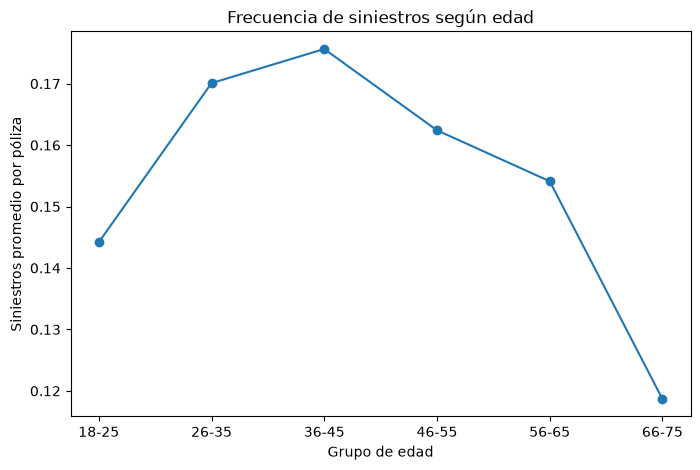

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    freq_edad["grupo_edad"].astype(str),
    freq_edad["frecuencia"],
    marker="o"
)

plt.title("Frecuencia de siniestros según edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Siniestros promedio por póliza")

plt.show()

### 3.5 Frecuencia por Antigüedad del vehículo

La frecuencia presenta una tendencia general creciente conforme aumenta la antigüedad del vehículo. Se observan fluctuaciones alrededor de esta tendencia

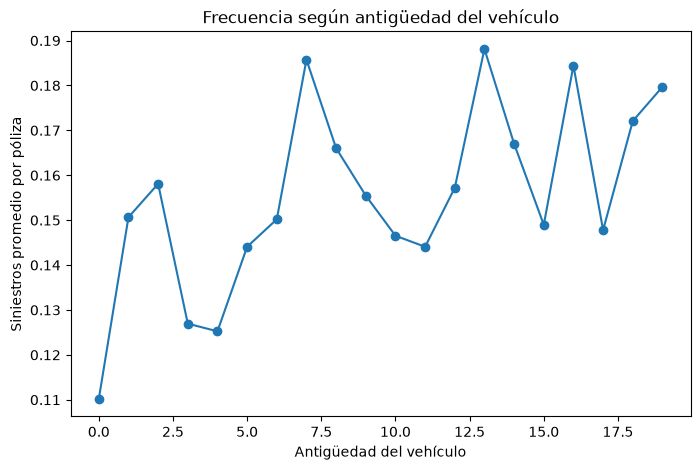

In [57]:
freq_antiguedad = frequency_summary(
    df,
    "anios_vehiculo"
)

plt.figure(figsize=(8, 5))

plt.plot(
    freq_antiguedad["anios_vehiculo"],
    freq_antiguedad["frecuencia"],
    marker="o"
)

plt.title("Frecuencia según antigüedad del vehículo")
plt.xlabel("Antigüedad del vehículo")
plt.ylabel("Siniestros promedio por póliza")

plt.show()

### Conclusiones del análisis de frecuencia

La cartera presenta una frecuencia media de aproximadamente 0.1554 siniestros
por póliza, mientras que el 14.23% de las pólizas registró al menos un siniestro.
La diferencia entre ambas cantidades se explica por la existencia de pólizas
con múltiples siniestros.

La distribución del conteo se encuentra fuertemente concentrada en cero:
aproximadamente el 86% de las pólizas no presentó siniestros durante el período
observado y poco más del 1% presentó dos o más.

La media y la varianza del número de siniestros son similares, con una razón
varianza/media cercana a 1.025. Por tanto, no se observa inicialmente una
sobredispersión marginal importante y un modelo Poisson constituye un punto
de partida razonable. Esta hipótesis deberá evaluarse nuevamente después del
ajuste del modelo mediante diagnósticos de dispersión residual.

El análisis por factores de riesgo muestra diferencias importantes entre
segmentos. La zona y, particularmente, el historial de siniestros presentan
una clara relación creciente con la frecuencia observada. La cobertura y el
tipo de uso también muestran diferencias entre categorías, aunque de menor
magnitud.

La edad presenta una relación aparentemente no lineal con la frecuencia:
esta aumenta inicialmente hasta alcanzar su máximo alrededor de las edades
intermedias y posteriormente disminuye. Por otro lado, la antigüedad del
vehículo presenta una tendencia general creciente, acompañada de fluctuaciones
que podrían atribuirse a variabilidad muestral.

En conjunto, el análisis sugiere que existen tanto efectos aproximadamente
monótonos como relaciones no lineales entre las características de las pólizas
y su frecuencia de siniestros. Estas estructuras serán relevantes al comparar
posteriormente modelos estadísticos clásicos con métodos de Machine Learning
y Deep Learning.

## 4. Análisis de severidad

La severidad representa el costo de los siniestros ocurridos. A diferencia
de la frecuencia, esta variable únicamente se encuentra definida para las
pólizas que presentaron al menos un siniestro.

Por esta razón, el análisis de severidad se realizará condicionando a:

$$N_i > 0.$$

El objetivo es estudiar su distribución, dispersión, asimetría y relación
con las características del riesgo antes de ajustar modelos predictivos.

In [58]:
df_severity = df.loc[
    df["numero_siniestros"] > 0
].copy()

print(f"Pólizas con siniestros: {len(df_severity):,}")
print(
    f"Proporción del portafolio: "
    f"{len(df_severity) / len(df):.2%}"
)

Pólizas con siniestros: 1,423
Proporción del portafolio: 14.23%


### 4.1 Distribución de la severidad

La severidad presenta una distribución claramente asimétrica a la derecha.
La media observada ($12,422) es superior a la mediana ($10,135), mientras que
el coeficiente de asimetría es aproximadamente 2.3.

También se observa una cola derecha pronunciada. Mientras que el 99% de las
observaciones se encuentra por debajo de aproximadamente $42,461, el valor
máximo alcanza aproximadamente $90,381.

In [59]:
df_severity["severidad_promedio"].describe(
    percentiles=[0.50,0.90, 0.95, 0.99]
)

count     1423.000000
mean     12422.470478
std       8742.437938
min       1305.626001
50%      10135.257484
90%      22529.425977
95%      29538.094402
99%      42461.018294
max      90380.891559
Name: severidad_promedio, dtype: float64

In [60]:
severity = df_severity["severidad_promedio"]

print(f"Media: ${severity.mean():,.2f}")
print(f"Mediana: ${severity.median():,.2f}")
print(f"Desviación estándar: ${severity.std():,.2f}")
print(f"Asimetría: {severity.skew():.3f}")
print(f"Máximo: ${severity.max():,.2f}")

Media: $12,422.47
Mediana: $10,135.26
Desviación estándar: $8,742.44
Asimetría: 2.296
Máximo: $90,380.89


En el histograma podemos observar una clara concentración de la severidad en montos de 10,000 hasta 20,000 pesos, pero hay algunos valores que tenemos que considerar los cuales superan los $50,000

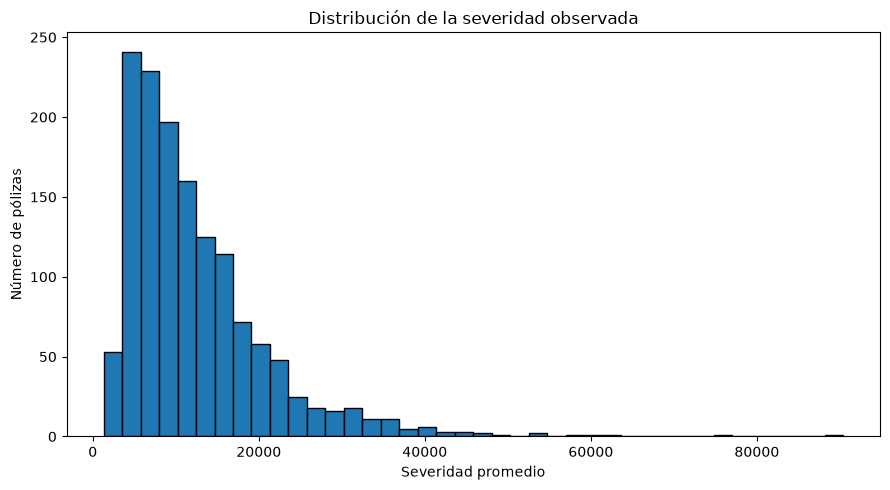

In [61]:
plt.figure(figsize=(9, 5))

plt.hist(
    severity,
    bins=40,
    edgecolor="black"
)

plt.title("Distribución de la severidad observada")
plt.xlabel("Severidad promedio")
plt.ylabel("Número de pólizas")

plt.tight_layout()
plt.show()

El boxplot identifica numerosas observaciones por encima de sus bigotes. Sin
embargo, estas observaciones no deben considerarse automáticamente errores o
datos atípicos que deban eliminarse. En variables de pérdidas monetarias, la
asimetría y la presencia de siniestros de elevada severidad forman parte
natural del fenómeno que se pretende modelar.

Este comportamiento hace relevante considerar distribuciones positivas y
asimétricas para la modelación de severidad. Entre ellas se encuentran
distribuciones como Gamma y Lognormal. Para la posterior construcción de un
GLM, la distribución Gamma resulta particularmente relevante al pertenecer a
la familia exponencial.

C:\Users\derec\AppData\Local\Temp\ipykernel_13332\132217813.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


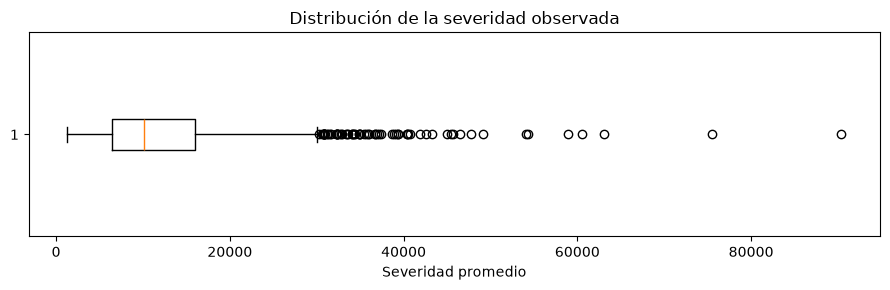

In [62]:
plt.figure(figsize=(9, 3))

plt.boxplot(
    severity,
    vert=False
)

plt.title("Distribución de la severidad observada")
plt.xlabel("Severidad promedio")

plt.tight_layout()
plt.show()

### 4.2 Transformación logarítmica

Al aplicar el logaritmo a la severidad se observa una reducción considerable
de la asimetría. El coeficiente pasa de aproximadamente 2.3 en la escala
original a 0.06 en escala logarítmica.

El histograma de `log(severidad)` presenta además una forma aproximadamente
simétrica y acampanada, concentrada alrededor de 9.2.

Estos resultados sugieren que una distribución Lognormal podría representar
adecuadamente el comportamiento de la severidad, ya que una variable
Lognormal se caracteriza por presentar una distribución aproximadamente
Normal después de aplicar el logaritmo.

Este resultado será relevante posteriormente al comparar diferentes
estrategias de modelación de severidad.

In [66]:
df_severity["log_severidad"] = np.log(
    df_severity["severidad_promedio"]
)


np.float64(9.224441225645315)

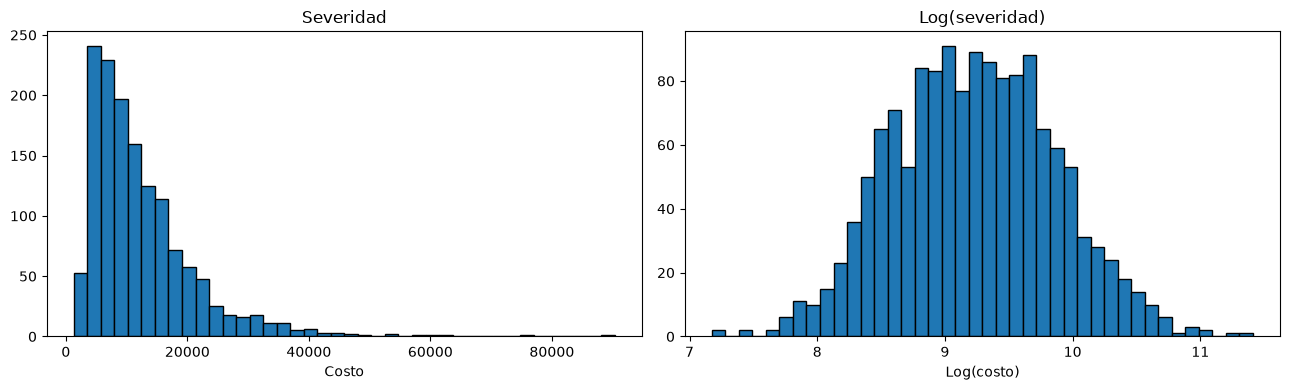

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    df_severity["severidad_promedio"],
    bins=40,
    edgecolor="black"
)
axes[0].set_title("Severidad")
axes[0].set_xlabel("Costo")

axes[1].hist(
    df_severity["log_severidad"],
    bins=40,
    edgecolor="black"
)
axes[1].set_title("Log(severidad)")
axes[1].set_xlabel("Log(costo)")

plt.tight_layout()
plt.show()

In [65]:
print(
    "Asimetría severidad:",
    df_severity["severidad_promedio"].skew()
)

print(
    "Asimetría log-severidad:",
    df_severity["log_severidad"].skew()
)

Asimetría severidad: 2.2959175978384248
Asimetría log-severidad: 0.0681313779220631


### 4.3 Severidad según factores de riesgo

Una vez estudiada la distribución marginal de la severidad, analizaremos su
relación con las características del riesgo.

El objetivo es identificar qué variables presentan diferencias relevantes en
el costo de los siniestros y determinar si los factores asociados con una mayor
frecuencia son necesariamente los mismos que explican una mayor severidad.

El análisis se realiza únicamente sobre pólizas que registraron al menos un
siniestro durante el período observado.

In [67]:
def severity_summary(df, variable):
    return (
        df.groupby(variable, observed=True)
        .agg(
            polizas=("severidad_promedio", "size"),
            severidad_media=("severidad_promedio", "mean"),
            severidad_mediana=("severidad_promedio", "median"),
            desviacion=("severidad_promedio", "std")
        )
        .reset_index()
    )

In [68]:
severity_summary(df_severity, "zona_cat")
severity_summary(df_severity, "cobertura_cat")
severity_summary(df_severity, "historial_siniestros")
severity_summary(df_severity, "tipo_uso_cat")

,tipo_uso_cat,polizas,severidad_media,severidad_mediana,desviacion
0,Carga comercial,137,13545.105586,12124.799274,8823.842357
1,Particular,670,12310.870805,9913.579351,8539.872287
2,Transporte privado,616,12294.176274,9917.271903,8936.438700


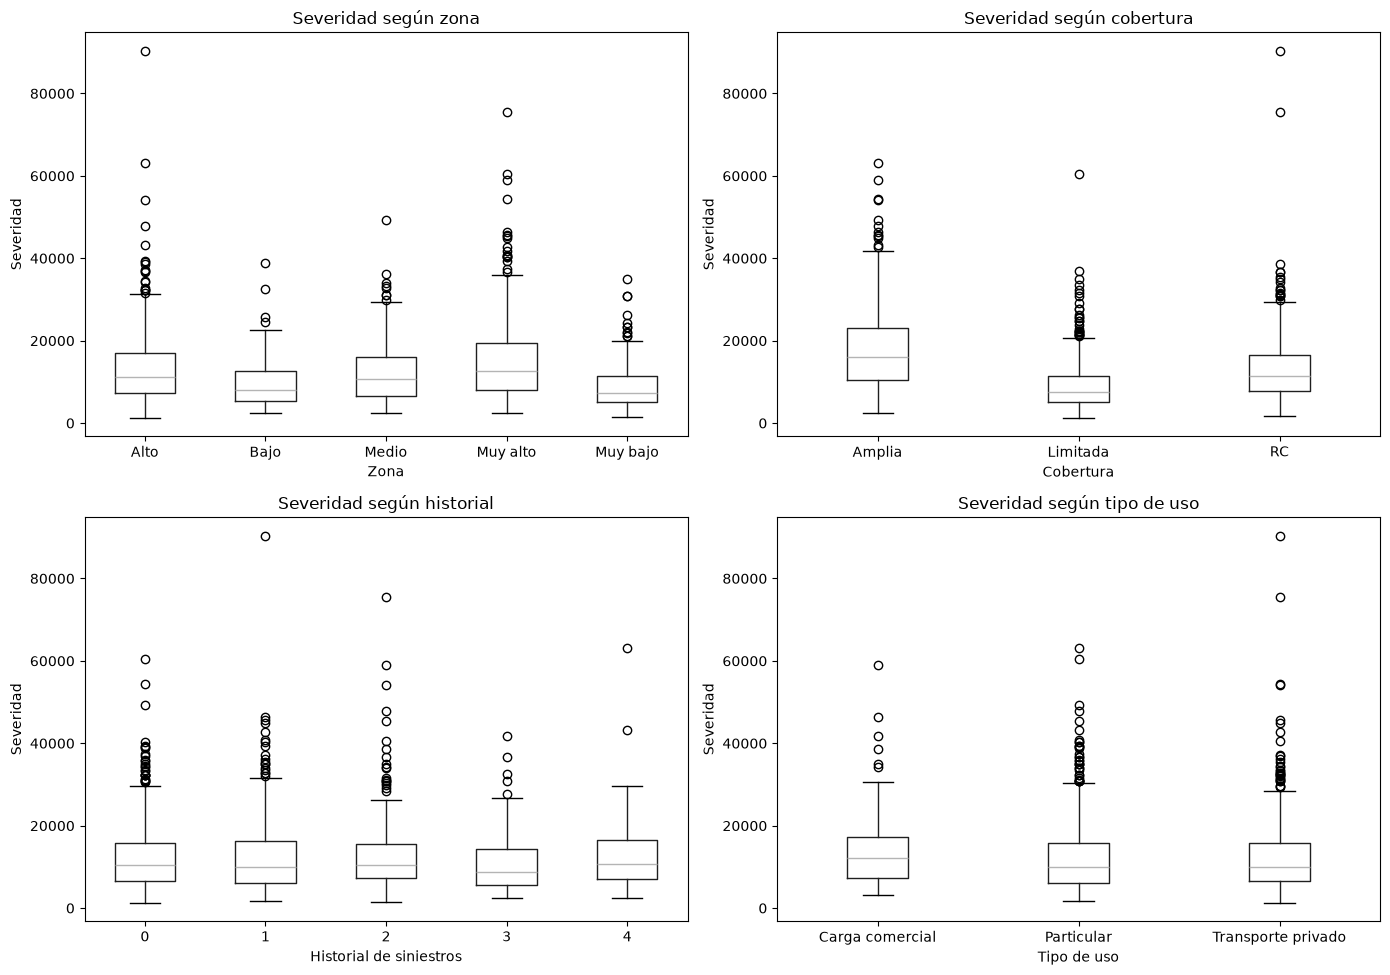

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_severity.boxplot(
    column="severidad_promedio",
    by="zona_cat",
    ax=axes[0, 0],
    grid=False
)
axes[0, 0].set_title("Severidad según zona")
axes[0, 0].set_xlabel("Zona")
axes[0, 0].set_ylabel("Severidad")

df_severity.boxplot(
    column="severidad_promedio",
    by="cobertura_cat",
    ax=axes[0, 1],
    grid=False
)
axes[0, 1].set_title("Severidad según cobertura")
axes[0, 1].set_xlabel("Cobertura")
axes[0, 1].set_ylabel("Severidad")

df_severity.boxplot(
    column="severidad_promedio",
    by="historial_siniestros",
    ax=axes[1, 0],
    grid=False
)
axes[1, 0].set_title("Severidad según historial")
axes[1, 0].set_xlabel("Historial de siniestros")
axes[1, 0].set_ylabel("Severidad")

df_severity.boxplot(
    column="severidad_promedio",
    by="tipo_uso_cat",
    ax=axes[1, 1],
    grid=False
)
axes[1, 1].set_title("Severidad según tipo de uso")
axes[1, 1].set_xlabel("Tipo de uso")
axes[1, 1].set_ylabel("Severidad")

plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.4 Severidad vs antigüedad del vehículo

In [70]:
sev_antiguedad = (
    df_severity
    .groupby("anios_vehiculo")
    .agg(
        severidad_media=("severidad_promedio", "mean"),
        severidad_mediana=("severidad_promedio", "median"),
        polizas=("severidad_promedio", "size")
    )
    .reset_index()
)

sev_antiguedad

,anios_vehiculo,severidad_media,severidad_mediana,polizas
0,0,10869.433683,9145.009612,46
1,1,10182.153598,8648.485908,63
2,2,10764.411510,9260.118414,76
3,3,11033.174701,8352.551068,61
4,4,10898.296341,9532.014763,56
5,5,10355.330624,7343.955962,63
6,6,12565.054195,9328.706362,76
7,7,12937.382822,8920.932221,77
8,8,11155.783056,10090.012291,77
9,9,13242.002520,9169.730768,72


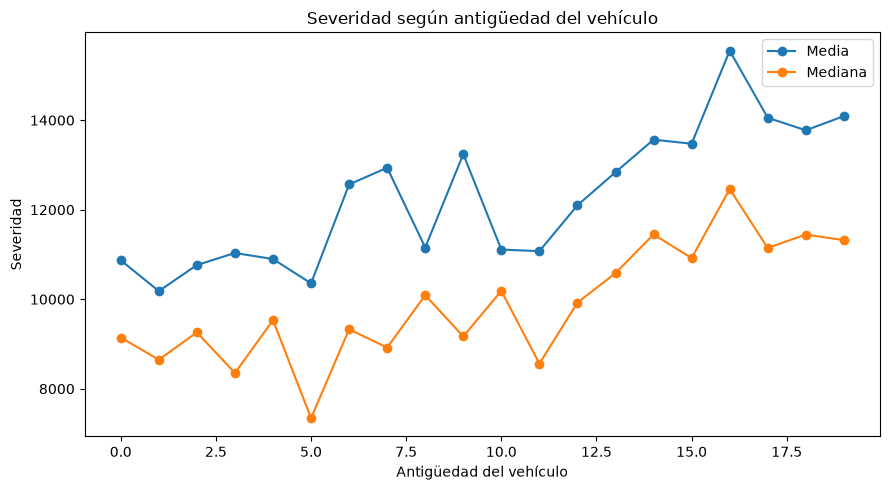

In [71]:
plt.figure(figsize=(9, 5))

plt.plot(
    sev_antiguedad["anios_vehiculo"],
    sev_antiguedad["severidad_media"],
    marker="o",
    label="Media"
)

plt.plot(
    sev_antiguedad["anios_vehiculo"],
    sev_antiguedad["severidad_mediana"],
    marker="o",
    label="Mediana"
)

plt.title("Severidad según antigüedad del vehículo")
plt.xlabel("Antigüedad del vehículo")
plt.ylabel("Severidad")
plt.legend()

plt.tight_layout()
plt.show()

In [72]:
sev_edad = (
    df_severity
    .groupby("grupo_edad", observed=True)
    .agg(
        severidad_media=("severidad_promedio", "mean"),
        severidad_mediana=("severidad_promedio", "median"),
        polizas=("severidad_promedio", "size")
    )
    .reset_index()
)

sev_edad

,grupo_edad,severidad_media,severidad_mediana,polizas
0,18-25,12779.498606,10485.560189,188
1,26-35,11785.439152,9568.893512,277
2,36-45,12169.195800,10065.862314,286
3,46-55,12727.706398,10373.863547,264
4,56-65,12319.089279,9852.872666,241
5,66-75,13177.593428,10293.717874,167


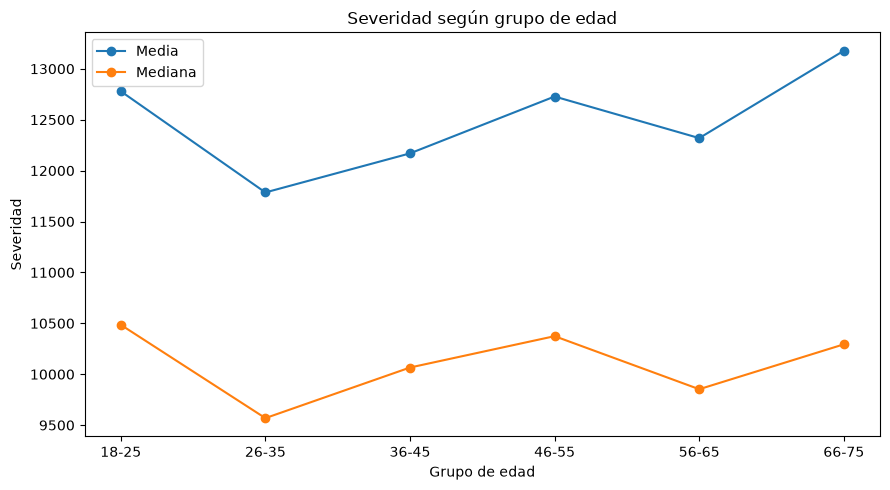

In [73]:
plt.figure(figsize=(9, 5))

plt.plot(
    sev_edad["grupo_edad"].astype(str),
    sev_edad["severidad_media"],
    marker="o",
    label="Media"
)

plt.plot(
    sev_edad["grupo_edad"].astype(str),
    sev_edad["severidad_mediana"],
    marker="o",
    label="Mediana"
)

plt.title("Severidad según grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Severidad")
plt.legend()

plt.tight_layout()
plt.show()